In [119]:
!pip install tensorflow

In [120]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [121]:
#import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [122]:
df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
df

,Year,Month,Month_Name,Oil,Coal_Lignite,Natural_Gas,Total_CO2
0,1987,1,JAN,2887.26,703.79,522.03,4113.08
1,1987,2,FEB,2506.05,697.51,523.50,3727.06
2,1987,3,MAR,2756.09,686.68,605.84,4048.62
3,1987,4,APR,2699.84,741.40,593.62,4034.86
4,1987,5,MAY,2740.84,1370.03,678.79,4789.66
...,...,...,...,...,...,...,...
466,2025,11,NOV,8638.57,4501.77,5847.82,18988.16
467,2025,12,DEC,9350.42,4518.88,6248.92,20118.22
468,2026,1,JAN,9258.40,3488.06,6339.66,19086.12
469,2026,2,FEB,8498.87,3755.73,6653.14,18907.74


In [123]:
pd.DataFrame(df['Year'])

,Year
0,1987
1,1987
2,1987
3,1987
4,1987
...,...
466,2025
467,2025
468,2026
469,2026


In [124]:
df.head()

,Year,Month,Month_Name,Oil,Coal_Lignite,Natural_Gas,Total_CO2
0,1987,1,JAN,2887.26,703.79,522.03,4113.08
1,1987,2,FEB,2506.05,697.51,523.50,3727.06
2,1987,3,MAR,2756.09,686.68,605.84,4048.62
3,1987,4,APR,2699.84,741.40,593.62,4034.86
4,1987,5,MAY,2740.84,1370.03,678.79,4789.66


In [125]:
monthly = df.groupby(['Year','Month'])['Total_CO2'].sum().reset_index()
monthly

,Year,Month,Total_CO2
0,1987,1,4113.08
1,1987,2,3727.06
2,1987,3,4048.62
3,1987,4,4034.86
4,1987,5,4789.66
...,...,...,...
466,2025,11,18988.16
467,2025,12,20118.22
468,2026,1,19086.12
469,2026,2,18907.74


In [126]:
monthly['lag1'] = monthly['Total_CO2'].shift(1)
monthly['lag2'] = monthly['Total_CO2'].shift(2)
monthly['lag3'] = monthly['Total_CO2'].shift(3)
monthly['rolling_mean_3'] = monthly['Total_CO2'].rolling(3).mean()
monthly['rolling_mean_6'] = monthly['Total_CO2'].rolling(6).mean()
monthly.dropna(inplace=True)
X= monthly[['Year','Month','lag1','lag2','lag3', 'rolling_mean_3', 'rolling_mean_6']]
Y= monthly['Total_CO2']

In [127]:
# Chronological split — never shuffle time series data
split_idx = int(len(monthly) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
Y_train = Y.iloc[:split_idx]
Y_test  = Y.iloc[split_idx:]

print(f"Train: {monthly['Year'].iloc[0]}-{monthly['Month'].iloc[0]:02d}  →  {monthly['Year'].iloc[split_idx-1]}-{monthly['Month'].iloc[split_idx-1]:02d}")
print(f"Test:  {monthly['Year'].iloc[split_idx]}-{monthly['Month'].iloc[split_idx]:02d}  →  {monthly['Year'].iloc[-1]}-{monthly['Month'].iloc[-1]:02d}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train: 1987-06  →  2018-05
Test:  2018-06  →  2026-03
Train size: 372, Test size: 94


In [128]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc_X=StandardScaler()
X_train=sc_X.fit_transform(X_train)
X_test=sc_X.transform(X_test)

# Scale Y as well for better neural network training
sc_Y = StandardScaler()
Y_train_scaled = sc_Y.fit_transform(Y_train.values.reshape(-1, 1))
Y_test_scaled = sc_Y.transform(Y_test.values.reshape(-1, 1))

In [129]:
X_train

array([[-1.72102331, -0.14484136, -1.83208625, ..., -1.95238941,
        -1.93540693, -1.95129391],
       [-1.72102331,  0.14484136, -1.97604705, ..., -1.95507215,
        -1.90760845, -1.93996216],
       [-1.72102331,  0.43452409, -1.8964786 , ..., -1.80791145,
        -1.95357761, -1.92823409],
       ...,
       [ 1.73962897, -1.01388955,  1.26863995, ...,  1.37425352,
         1.60950481,  1.50938706],
       [ 1.73962897, -0.72420682,  1.9209675 , ...,  1.63897512,
         1.55975014,  1.52038419],
       [ 1.73962897, -0.43452409,  1.47442694, ...,  1.28526692,
         1.65573409,  1.55137765]])

In [130]:
X_test

array([[ 1.73962897, -0.14484136,  1.55566642,  1.48030793,  1.93600655,
         1.55509799,  1.59517225],
       [ 1.73962897,  0.14484136,  1.62002945,  1.56136102,  1.49055298,
         1.58629899,  1.5859047 ],
       [ 1.73962897,  0.43452409,  1.56772911,  1.62557639,  1.5715947 ,
         1.58723164,  1.63431447],
       [ 1.73962897,  0.72420682,  1.55845538,  1.57339604,  1.63580106,
         1.48876672,  1.53486367],
       [ 1.73962897,  1.01388955,  1.325584  ,  1.56414358,  1.58362803,
         1.46060092,  1.53637975],
       [ 1.73962897,  1.30357228,  1.48350328,  1.33180648,  1.57437687,
         1.40677187,  1.50995804],
       [ 1.73962897,  1.59325501,  1.3974872 ,  1.48936345,  1.34207235,
         1.45307697,  1.48390425],
       [ 1.85126292, -1.59325501,  1.46405287,  1.40354471,  1.49960722,
         1.42337659,  1.45500014],
       [ 1.85126292, -1.30357228,  1.39468847,  1.46995766,  1.41380052,
         1.33202386,  1.38248197],
       [ 1.85126292, -1.0138

In [131]:
X_train.shape

(372, 7)

In [132]:
#now lets create the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [133]:
# Renamed from classifier — this is a regression model, not a classifier
regressor = Sequential()

In [134]:
regressor.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [135]:
regressor.add(Dense(units=32, activation='relu'))
regressor.add(Dense(units=16, activation='relu'))
regressor.add(Dense(units=1,  activation='linear'))

In [136]:
regressor.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [137]:
#early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [138]:
model_history = regressor.fit(
    X_train, Y_train_scaled,
    validation_split=0.2,
    batch_size=8,
    epochs=100,
    callbacks=early_stopping
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.2416 - mean_absolute_error: 0.3453 - val_loss: 0.5231 - val_mean_absolute_error: 0.6995
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0201 - mean_absolute_error: 0.1034 - val_loss: 0.0703 - val_mean_absolute_error: 0.2247
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0112 - mean_absolute_error: 0.0813 - val_loss: 0.0490 - val_mean_absolute_error: 0.1849
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0097 - mean_absolute_error: 0.0767 - val_loss: 0.0299 - val_mean_absolute_error: 0.1372
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0091 - mean_absolute_error: 0.0731 - val_loss: 0.0339 - val_mean_absolute_error: 0.1487
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0086 - mean_absolute_error: 0.0716 - val_loss: 0.0343 - val_mean_absolute_error: 0.1540
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0083 - mean_absolute_error: 0.0700 - v

In [139]:
model_history.history.keys()

dict_keys(['loss', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_error'])

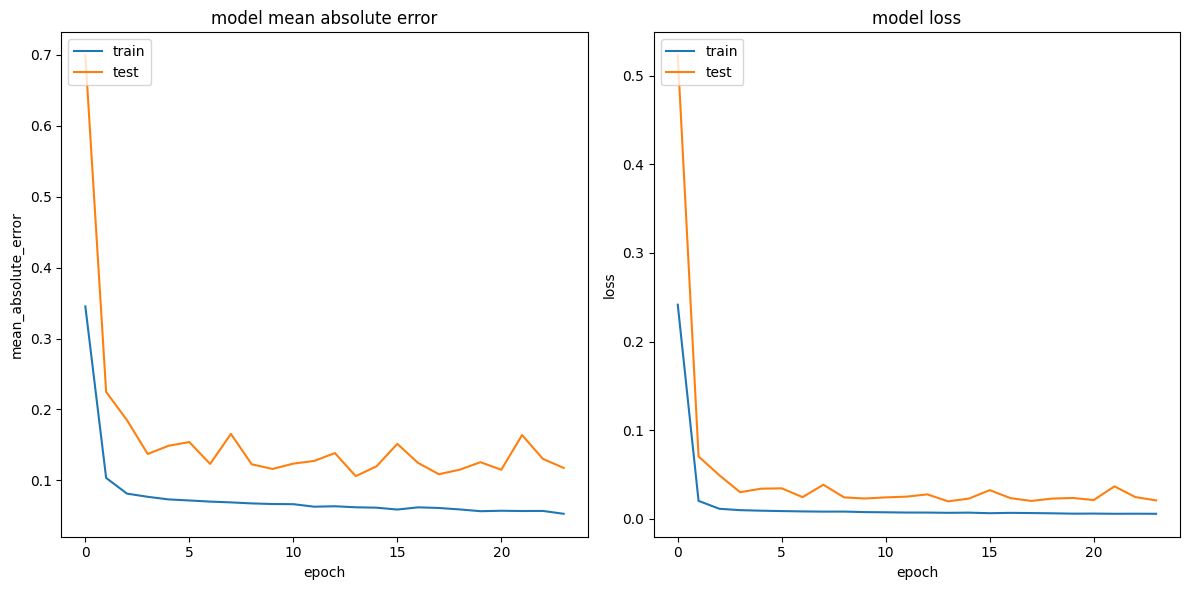

In [140]:
#summarize history for mean_absolute_error and loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(model_history.history['mean_absolute_error'])
plt.plot(model_history.history['val_mean_absolute_error'])
plt.title('model mean absolute error')
plt.ylabel('mean_absolute_error')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.tight_layout()
plt.show()

In [141]:
Y_pred_scaled = regressor.predict(X_test)
Y_pred = sc_Y.inverse_transform(Y_pred_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [142]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Predict on train set
Y_train_pred_scaled = regressor.predict(X_train)
Y_train_pred = sc_Y.inverse_transform(Y_train_pred_scaled)

train_r2   = r2_score(Y_train, Y_train_pred)
test_r2    = r2_score(Y_test, Y_pred)
train_mape = mean_absolute_percentage_error(Y_train, Y_train_pred)
test_mape  = mean_absolute_percentage_error(Y_test, Y_pred)

# Reconstruct X_test_raw from the original X DataFrame
X_test_raw = X.iloc[split_idx:]

# Naive persistence baseline: predict lag1 as the forecast
# This is the dumbest possible model — ANN must clearly beat it
naive_r2   = r2_score(Y_test, X_test_raw['lag1'])
naive_mape = mean_absolute_percentage_error(Y_test, X_test_raw['lag1'])

print(f"Training R2:   {train_r2:.4f}    Training MAPE: {train_mape*100:.2f}%")
print(f"Test R2:       {test_r2:.4f}    Test MAPE:     {test_mape*100:.2f}%")
print(f"Gap (overfit): {train_r2 - test_r2:.4f}")
print()
print(f"Naive baseline (lag1 only) — R2: {naive_r2:.4f}, MAPE: {naive_mape*100:.2f}%")
print(f"ANN improvement over naive  — R2: +{test_r2 - naive_r2:.4f}, MAPE: -{(naive_mape - test_mape)*100:.2f}pp")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Training R2:   0.9913    Training MAPE: 2.46%
Test R2:       -0.4956    Test MAPE:     4.95%
Gap (overfit): 1.4868

Naive baseline (lag1 only) — R2: -0.2018, MAPE: 4.10%
ANN improvement over naive  — R2: +-0.2938, MAPE: --0.85pp


In [143]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, Y_pred)
r2

-0.4955770629231566

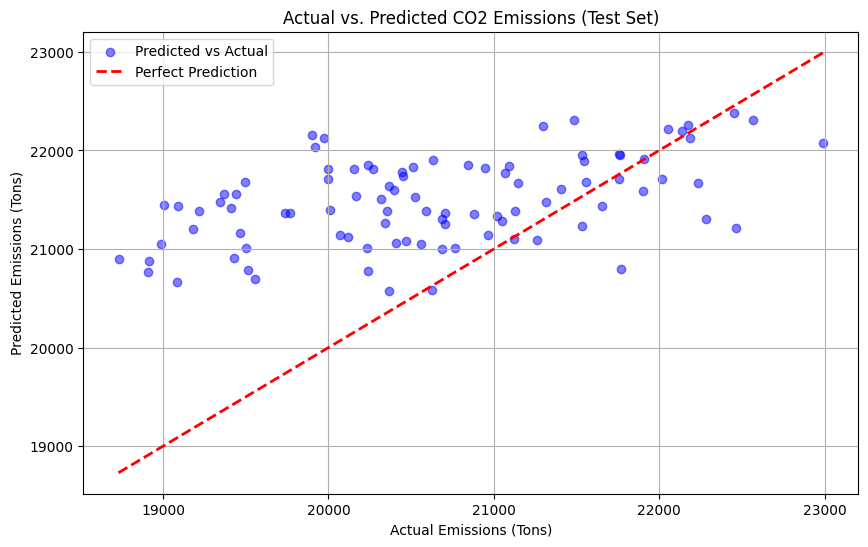

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training R2: 0.9925
Test R2: -0.4956
Difference: 1.4880


In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Emissions (Tons)')
plt.ylabel('Predicted Emissions (Tons)')
plt.title('Actual vs. Predicted CO2 Emissions (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

# Calculate the difference between Train and Test R2
from sklearn.metrics import r2_score
Y_train_pred_scaled = regressor.predict(X_train)
Y_train_pred = sc_Y.inverse_transform(Y_train_pred_scaled)
train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_pred)

print(f'Training R2: {train_r2:.4f}')
print(f'Test R2: {test_r2:.4f}')
print(f'Difference: {train_r2 - test_r2:.4f}')

In [145]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE
mape = mean_absolute_percentage_error(Y_test, Y_pred)

print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"Accuracy in percentage terms: {(1 - mape) * 100:.2f}%")

Mean Absolute Percentage Error (MAPE): 0.0495
Accuracy in percentage terms: 95.05%


In [146]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE for Training data
train_mape = mean_absolute_percentage_error(Y_train, Y_train_pred)

# Calculate MAPE for Test data
test_mape = mean_absolute_percentage_error(Y_test, Y_pred)

print(f"Training MAPE: {train_mape:.4f} (Accuracy: {(1 - train_mape) * 100:.2f}%)")
print(f"Test MAPE:     {test_mape:.4f} (Accuracy: {(1 - test_mape) * 100:.2f}%)")
print(f"Difference:    {abs(train_mape - test_mape):.4f}")

Training MAPE: 0.0266 (Accuracy: 97.34%)
Test MAPE:     0.0495 (Accuracy: 95.05%)
Difference:    0.0229


In [148]:
import matplotlib.pyplot as plt

# Data for plotting (converting MAPE to percentage)
metrics = ['R2 Score', 'MAPE (%)']
train_values = [train_r2, train_mape * 100]
test_values = [test_r2, test_mape * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot R2 Score Comparison
ax1.bar(['Train', 'Test'], [train_r2, test_r2], color=['blue', 'orange'], alpha=0.7)
ax1.set_title('R2 Score Comparison (Higher is Better)')
ax1.set_ylabel('R2 Score')
ax1.set_ylim(0.99, 1.0)
for i, v in enumerate([train_r2, test_r2]):
    ax1.text(i, v, f'{v:.4f}', ha='center', va='bottom')

# Plot MAPE Comparison in Percentages
ax2.bar(['Train', 'Test'], [train_mape * 100, test_mape * 100], color=['green', 'red'], alpha=0.7)
ax2.set_title('MAPE Comparison in % (Lower is Better)')
ax2.set_ylabel('Percentage Error (%)')
for i, v in enumerate([train_mape * 100, test_mape * 100]):
    ax2.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1924/1968471150.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
